# Test Phase Field
This notebook is to test the validity of the calculation based on phase field $\phi(x, y, z)$. 

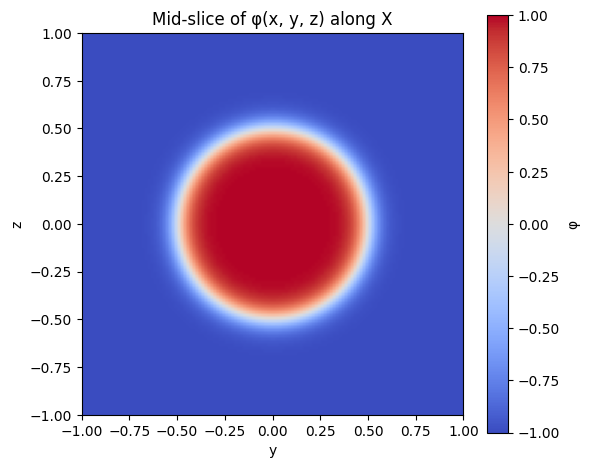

In [1]:
# Generation of the mock phase field and its visualization

from pinn.test_phase import generate_phase_field, visualize_phase_slice

radius = 0.5
epsilon = 0.05
grid_size = 128

phi, (x, y, z) = generate_phase_field(R=radius, epsilon=epsilon, grid_size=grid_size)
visualize_phase_slice(phi, x, y, z, axis='x')

In [16]:
# Calculate the volume and surface area of the sphere expressed by the phase field using fininte difference method (FDM)

from pinn.test_phase import compute_volume_fdm, compute_surface_area_fdm
import numpy as np

volume_fdm = compute_volume_fdm(phi, x, y, z)
area_fdm = compute_surface_area_fdm(phi, x, y, z, epsilon=epsilon)

print("Volume (true ) = ", 4*np.pi/3*radius**3)
print("Volume (phase) = ", volume_fdm)

print("Surface area (true ) = ", 4*np.pi*radius**2)
print("Surface area (phase) = ", area_fdm)

Volume (true ) =  0.5235987755982988
Volume (phase) =  0.549437311181059
Surface area (true ) =  3.141592653589793
Surface area (phase) =  3.1487338635359787


In [2]:
# Calculate the volume and surface area based on analytical representation of the field using autodiff

from pinn.test_phase import compute_volume_autodiff, compute_surface_area_autodiff, analytic_phi_fn
import jax

# Generate sample points in the cube [-1, 1]^3
N = 100000
key = jax.random.PRNGKey(0)
x_batch = jax.random.uniform(key, (N, 3), minval=-1.0, maxval=1.0)

phi_fn = lambda x: analytic_phi_fn(x, R=0.5, epsilon=0.05)
volume = compute_volume_autodiff(phi_fn, x_batch, V_box=8.0)
area = compute_surface_area_autodiff(phi_fn, x_batch, epsilon=0.05, V_box=8.0)

print("Volume (autodiff):", volume)
print("Surface area (autodiff):", area)


Volume (autodiff): 0.54876333
Surface area (autodiff): 3.1752183


  0%|          | 0/7000 [00:00<?, ?it/s]

Step 1/7000, Loss: 1.123129, Volume: 3.9861, Area: 6601.0020
Step 100/7000, Loss: 0.137010, Volume: 0.7843, Area: 2190.3513
Step 200/7000, Loss: 0.113078, Volume: 0.5481, Area: 934.5026
Step 300/7000, Loss: 0.079630, Volume: 0.5238, Area: 485.2208
Step 400/7000, Loss: 0.034988, Volume: 0.5115, Area: 211.3455
Step 500/7000, Loss: 0.018809, Volume: 0.5317, Area: 103.8443
Step 600/7000, Loss: 0.013732, Volume: 0.5369, Area: 59.8946
Step 700/7000, Loss: 0.010966, Volume: 0.5396, Area: 39.6414
Step 800/7000, Loss: 0.009060, Volume: 0.5412, Area: 28.0496
Step 900/7000, Loss: 0.007662, Volume: 0.5421, Area: 21.3926
Step 1000/7000, Loss: 0.006607, Volume: 0.5425, Area: 17.4796
Step 1100/7000, Loss: 0.005775, Volume: 0.5426, Area: 14.8427
Step 1200/7000, Loss: 0.005085, Volume: 0.5425, Area: 12.8867
Step 1300/7000, Loss: 0.004490, Volume: 0.5424, Area: 11.4012
Step 1400/7000, Loss: 0.003966, Volume: 0.5423, Area: 10.2572
Step 1500/7000, Loss: 0.003502, Volume: 0.5421, Area: 9.3468
Step 1600/700

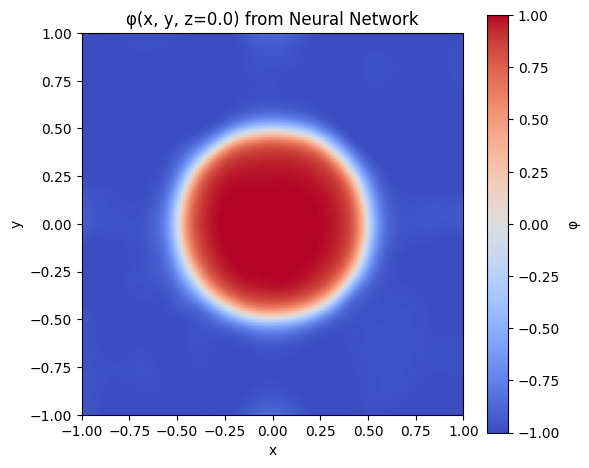

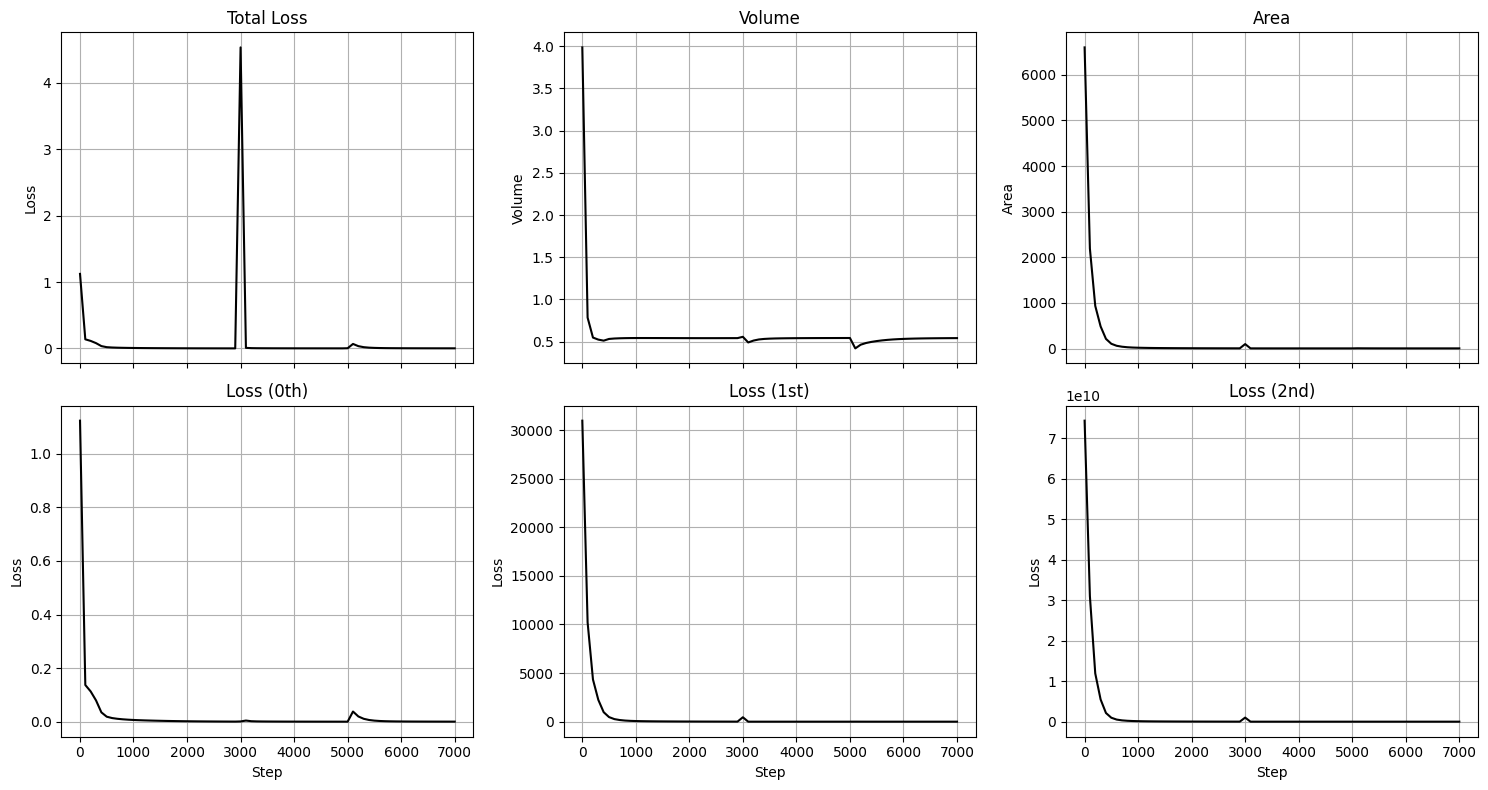

In [1]:
# # Train neural network so that it mimics the mock field function
from pinn.test_phase import train_neural_network, visualize_phi_slice_from_nn, save_checkpoint, plot_training_logs
import numpy as np

# state, model, training_logs = train_neural_network(learning_rate=1e-3, num_steps=7000, log_interval=100, alpha=0)
state, model, training_logs = train_neural_network(learning_rate=1e-3, num_steps=7000, switch_first=3000, switch_second=5000, log_interval=100, alpha=0.01, beta=1e-7)
# save_checkpoint(state)
# np.savez("logs_phasefield.npz", loss=loss, volume=volume, area=area)

phi_fn = lambda x: model.apply(state.params, x)

visualize_phi_slice_from_nn(phi_fn, grid_size=128, z_value=0.0)
plot_training_logs(training_logs)


# Convert training_logs (list of dicts) to a dict of lists
log_dict = {key: [entry[key] for entry in training_logs] for key in training_logs[0].keys()}
# Save to .npz file
np.savez("../outputs/logs/test_phase/training_logs.npz", **log_dict)



In [2]:
import jax
from pinn.test_phase import compute_volume_autodiff, compute_surface_area_autodiff

# Generate random evaluation points
N = 100000
key = jax.random.PRNGKey(0)
x_batch = jax.random.uniform(key, (N, 3), minval=-1.0, maxval=1.0)

# Evaluate φ using the trained model inside TrainState
phi_fn = lambda x: state.apply_fn(state.params, x)

# Compute volume and surface area
volume = compute_volume_autodiff(phi_fn, x_batch)
area = compute_surface_area_autodiff(phi_fn, x_batch, epsilon=0.05)

# Print results
print(f"Volume (nn, autodiff): {volume:.4f}")
print(f"Surface Area (nn, autodiff): {area:.4f}")

Volume (nn, autodiff): 0.5487
Surface Area (nn, autodiff): 3.1927


/Users/atsushi/simulation/pinn-exploration-model/venv/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


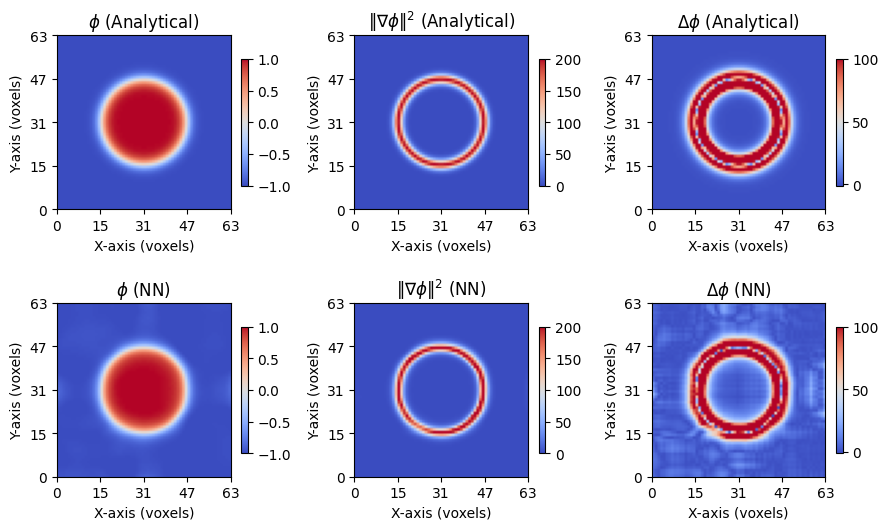

In [2]:
from pinn.plot import visualize_physics_loss
from pinn.test_phase import analytic_phi_fn
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.model import PINN

GRID_SIZE = 64
epsilon = 0.05

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/test_phase/7000/default/")
# checkpoint_dir = os.path.abspath(f"../outputs/logs/test_phase/phi_only/7000/default/")
# checkpoint_dir = os.path.abspath(f"../outputs/logs/test_phase/switch_3000_001/7000/default/")
checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_dir, target=None)

params = checkpoint_data["params"]
model = PINN()
phi_pinn = lambda x: model.apply(params, x)
phi_true = analytic_phi_fn

# Create a figure with horizontally arranged subplots
fig, axes = plt.subplots(2, 3, figsize=(9, 5.5))


visualize_physics_loss(axes[0,0], phi_fn=phi_true, epsilon = epsilon, component = "phi", grid_size = GRID_SIZE, slice_index=32, axis="z", title="Analytical", vmin=-1, vmax=1)
axes[0,0].set_title(r"$\phi$ (Analytical)")
visualize_physics_loss(axes[0,1], phi_fn=phi_true, epsilon = epsilon, component = "grad_norm2", grid_size = GRID_SIZE, slice_index=32, axis="z", title="Analytical", vmin=0, vmax=2e2)
axes[0,1].set_title(r"$\left\|\nabla \phi \right\|^2$ (Analytical)")
visualize_physics_loss(axes[0,2], phi_fn=phi_true, epsilon = epsilon, component = "laplacian", grid_size = GRID_SIZE, slice_index=32, axis="z", title="Analytical", vmin=-1, vmax=100)
axes[0,2].set_title(r"$\Delta\phi$ (Analytical)")

visualize_physics_loss(axes[1,0], phi_fn=phi_pinn, epsilon = epsilon, component = "phi", grid_size = GRID_SIZE, slice_index=32, axis="z", title="NN", vmin=-1, vmax=1)
axes[1,0].set_title(r"$\phi$ (NN)")
visualize_physics_loss(axes[1,1], phi_fn=phi_pinn, epsilon = epsilon, component = "grad_norm2", grid_size = GRID_SIZE, slice_index=32, axis="z", title="NN", vmin=0, vmax=2e2)
axes[1,1].set_title(r"$\left\|\nabla \phi \right\|^2$ (NN)")
visualize_physics_loss(axes[1,2], phi_fn=phi_pinn, epsilon = epsilon, component = "laplacian", grid_size = GRID_SIZE, slice_index=32, axis="z", title="NN", vmin=-1, vmax=100)
axes[1,2].set_title(r"$\Delta\phi$ (NN)")

# Adjust layout and add colorbar
plt.tight_layout()
plt.savefig("../outputs/figs/phase_initial.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
checkpoint_data.dire

dict_keys(['opt_state', 'params', 'step'])

In [13]:
phi_pinn([[0.0, 0.0, 0.0]])

Array(1.0338961, dtype=float32)